# CIFake: Real vs AI-Image Detector (Lightweight CPU Version)

| Setting | Value |
|---|---|
| Backbone | MobileNetV2 (small, fast) |
| Image Size | 96x96  |
| Batch Size | 32  |
| Epochs | Phase1=3, Phase2=8 |
| TTA | 3 views  |
| Expected Acc | ~97-98% |
| RAM needed | ~3 GB |



In [1]:
!pip install -q timm kaggle albumentations
print("Packages ready!")

Packages ready!


In [2]:
import os, random, time, warnings, zipfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix

warnings.filterwarnings('ignore')

# Reproducibility
random.seed(42); np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.11.0+cu128


## STEP 2: Kaggle Setup (FREE)
1. kaggle.com → Account → Settings → **Create New Token** → `kaggle.json` download hoga
2. Neeche cell mein upload karo — bilkul free hai!

In [3]:
import os
os.environ['KAGGLE_USERNAME'] = 'zafarullahzr'
os.environ['KAGGLE_KEY']      = 'KGAT_4af72b08a72f583031053ae9681285f4'
!mkdir -p ~/.kaggle
!echo '{"username":"'$KAGGLE_USERNAME'","key":"'$KAGGLE_KEY'"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

## STEP 3: Download Dataset

In [4]:
DATA_ROOT = Path('/content/cifake')

if not DATA_ROOT.exists():
    print("Downloading CIFake (~1.5 GB)...")
    !kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images -p /content
    with zipfile.ZipFile('/content/cifake-real-and-ai-generated-synthetic-images.zip') as z:
        z.extractall('/content/cifake')
    print("Done!")
else:
    print("Already downloaded!")

stats = {}
for split in ['train', 'test']:
    stats[split] = {}
    for cls in ['REAL', 'FAKE']:
        p = DATA_ROOT / split / cls
        imgs = list(p.glob('*.jpg')) + list(p.glob('*.png'))
        stats[split][cls] = imgs
        print(f"  {split}/{cls}: {len(imgs):,}")

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:00<00:00, 179MB/s] 

Done!
  train/REAL: 50,000
  train/FAKE: 50,000
  test/REAL: 10,000
  test/FAKE: 10,000


## STEP 4: Quick EDA

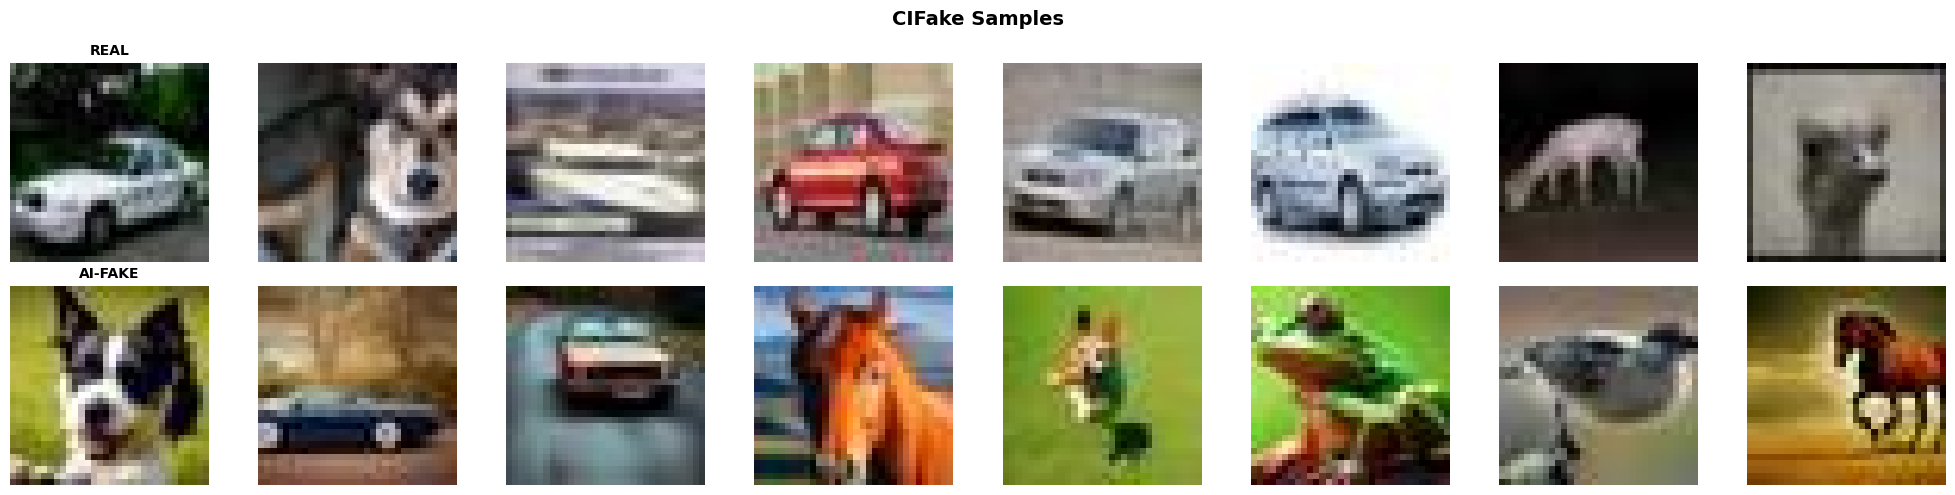

Saved samples.png


In [5]:
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('CIFake Samples', fontsize=14, fontweight='bold')
for r, cls in enumerate(['REAL', 'FAKE']):
    for c, p in enumerate(random.sample(stats['train'][cls], 8)):
        axes[r][c].imshow(Image.open(p))
        axes[r][c].axis('off')
        if c == 0:
            axes[r][c].set_title('REAL' if cls=='REAL' else 'AI-FAKE',
                                  fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('samples.png', dpi=100)
plt.show()
print("Saved samples.png")

## STEP 5: Config (Lightweight)

In [6]:
CFG = {
    'img_size'       : 96,
    'batch_size'     : 32,
    'num_workers'    : 2,
    'backbone'       : 'mobilenetv2_100',
    'dropout'        : 0.3,
    'phase1_epochs'  : 3,
    'phase2_epochs'  : 8,
    'phase1_lr'      : 5e-3,
    'phase2_lr'      : 1e-3,
    'weight_decay'   : 1e-4,
    'label_smoothing': 0.05,
    'use_mixup'      : True,
    'mixup_alpha'    : 0.2,
    'use_tta'        : True,
    'tta_views'      : 3,
    'norm_mean'      : [0.485, 0.456, 0.406],
    'norm_std'       : [0.229, 0.224, 0.225],
    'ckpt_dir'       : Path('/content/ckpts'),
}
CFG['ckpt_dir'].mkdir(exist_ok=True)
print("Config loaded!")
for k,v in CFG.items():
    if 'dir' not in k:
        print(f"  {k:18}: {v}")

Config loaded!
  img_size          : 96
  batch_size        : 32
  num_workers       : 2
  backbone          : mobilenetv2_100
  dropout           : 0.3
  phase1_epochs     : 3
  phase2_epochs     : 8
  phase1_lr         : 0.005
  phase2_lr         : 0.001
  weight_decay      : 0.0001
  label_smoothing   : 0.05
  use_mixup         : True
  mixup_alpha       : 0.2
  use_tta           : True
  tta_views         : 3
  norm_mean         : [0.485, 0.456, 0.406]
  norm_std          : [0.229, 0.224, 0.225]


## STEP 6: Transforms & Dataset

In [7]:
S = CFG['img_size']

train_tf = A.Compose([
    A.Resize(S, S),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.OneOf([
        A.GaussianBlur(blur_limit=3, p=1.0),
        A.RandomBrightnessContrast(0.2, 0.2, p=1.0),
    ], p=0.3),
    A.CoarseDropout(max_holes=4, max_height=12, max_width=12, p=0.2),
    A.Normalize(mean=CFG['norm_mean'], std=CFG['norm_std']),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(S, S),
    A.Normalize(mean=CFG['norm_mean'], std=CFG['norm_std']),
    ToTensorV2(),
])

tta_tfs = [
    A.Compose([A.Resize(S, S),
               A.Normalize(CFG['norm_mean'], CFG['norm_std']), ToTensorV2()]),
    A.Compose([A.Resize(S, S), A.HorizontalFlip(p=1.0),
               A.Normalize(CFG['norm_mean'], CFG['norm_std']), ToTensorV2()]),
    A.Compose([A.Resize(int(S*1.1), int(S*1.1)), A.CenterCrop(S, S),
               A.Normalize(CFG['norm_mean'], CFG['norm_std']), ToTensorV2()]),
]
print(f"Transforms ready! Image size: {S}x{S}")

Transforms ready! Image size: 96x96


In [8]:
class CIFakeDS(Dataset):
    def __init__(self, root, split, transform=None, tta_tfs=None):
        self.transform = transform
        self.tta_tfs   = tta_tfs
        self.paths, self.labels = [], []
        for cls, lbl in [('REAL', 0), ('FAKE', 1)]:
            imgs = list((root/split/cls).glob('*.jpg')) +                    list((root/split/cls).glob('*.png'))
            self.paths.extend(imgs)
            self.labels.extend([lbl]*len(imgs))
        print(f"[{split}] {len(self.paths):,} images "
              f"(REAL:{self.labels.count(0):,} FAKE:{self.labels.count(1):,})")

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        img = np.array(Image.open(self.paths[i]).convert('RGB'))
        lbl = self.labels[i]
        if self.tta_tfs:
            return torch.stack([t(image=img)['image'] for t in self.tta_tfs]), lbl
        return self.transform(image=img)['image'], lbl


def mixup(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def mixup_loss(crit, pred, ya, yb, lam):
    return lam*crit(pred,ya) + (1-lam)*crit(pred,yb)

print("Dataset class ready!")

Dataset class ready!


In [9]:
train_ds  = CIFakeDS(DATA_ROOT, 'train', transform=train_tf)
test_ds   = CIFakeDS(DATA_ROOT, 'test',  transform=val_tf)
tta_ds    = CIFakeDS(DATA_ROOT, 'test',  tta_tfs=tta_tfs)

train_dl  = DataLoader(train_ds, batch_size=CFG['batch_size'],
                        shuffle=True,  num_workers=CFG['num_workers'],
                        pin_memory=True, drop_last=True)
test_dl   = DataLoader(test_ds,  batch_size=64,
                        shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)
tta_dl    = DataLoader(tta_ds,   batch_size=16,
                        shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)

print(f"Train batches: {len(train_dl)} | Test batches: {len(test_dl)}")

[train] 100,000 images (REAL:50,000 FAKE:50,000)
[test] 20,000 images (REAL:10,000 FAKE:10,000)
[test] 20,000 images (REAL:10,000 FAKE:10,000)
Train batches: 3125 | Test batches: 313


## STEP 7: Model — MobileNetV2 (Lightweight)

In [10]:
class Detector(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            'mobilenetv2_100', pretrained=True,
            num_classes=0, global_pool='avg')
        feat = self.backbone.num_features  # 1280

        self.head = nn.Sequential(
            nn.Linear(feat, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(CFG['dropout']),
            nn.Linear(256, 2),
        )
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)

    def freeze(self):
        for p in self.backbone.parameters(): p.requires_grad = False
        total = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Backbone frozen | Trainable: {total:,}")

    def unfreeze(self):
        for p in self.backbone.parameters(): p.requires_grad = True
        total = sum(p.numel() for p in self.parameters())
        print(f"Backbone unfrozen | Total trainable: {total:,}")

    def forward(self, x):
        return self.head(self.backbone(x))


model = Detector().to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f"Model: MobileNetV2  |  Params: {total/1e6:.1f}M  |  Size: ~{total*4/1e6:.0f} MB")

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

Model: MobileNetV2  |  Params: 2.6M  |  Size: ~10 MB


## STEP 8: Training

In [11]:
def train_epoch(model, dl, opt, sched, crit, mixup_on=False):
    model.train()
    loss_sum, correct, total = 0., 0, 0
    for i, (imgs, lbls) in enumerate(dl):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        if mixup_on:
            imgs, ya, yb, lam = mixup(imgs, lbls, CFG['mixup_alpha'])
            out  = model(imgs)
            loss = mixup_loss(crit, out, ya, yb, lam)
        else:
            out  = model(imgs)
            loss = crit(out, lbls)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        loss_sum += loss.item()
        correct  += (out.argmax(1) == lbls).sum().item()
        total    += lbls.size(0)
    if sched: sched.step()
    return loss_sum/len(dl), 100.*correct/total


@torch.no_grad()
def evaluate(model, dl, crit):
    model.eval()
    loss_sum, preds, labels, probs = 0., [], [], []
    for imgs, lbls in dl:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        out  = model(imgs)
        loss_sum += crit(out, lbls).item()
        preds.append(out.argmax(1).cpu())
        labels.append(lbls.cpu())
        probs.append(F.softmax(out,1)[:,1].cpu())
    preds  = torch.cat(preds)
    labels = torch.cat(labels)
    probs  = torch.cat(probs)
    acc = (preds==labels).float().mean().item()*100
    return loss_sum/len(dl), acc, preds, labels, probs

history = defaultdict(list)
print("Training functions ready!")

Training functions ready!


In [12]:
# ── PHASE 1: Train head only ─────────────────────────────────────────────────
model.freeze()
crit    = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])
opt1    = torch.optim.AdamW(filter(lambda p:p.requires_grad, model.parameters()),
                             lr=CFG['phase1_lr'], weight_decay=CFG['weight_decay'])
sched1  = torch.optim.lr_scheduler.CosineAnnealingLR(
           opt1, T_max=CFG['phase1_epochs'], eta_min=1e-6)
best    = 0.

print(f"Phase 1: {CFG['phase1_epochs']} epochs (head only)")
print("="*55)
for ep in range(1, CFG['phase1_epochs']+1):
    t0 = time.time()
    tl, ta = train_epoch(model, train_dl, opt1, sched1, crit, mixup_on=False)
    vl, va, _, _, _ = evaluate(model, test_dl, crit)
    print(f"Ep {ep}/{CFG['phase1_epochs']}  "
          f"Train={ta:.2f}%  Val={va:.2f}%  "
          f"Loss={vl:.4f}  {time.time()-t0:.0f}s")
    history['p1_ta'].append(ta); history['p1_va'].append(va)
    if va > best:
        best = va
        torch.save(model.state_dict(), CFG['ckpt_dir']/'p1_best.pth')
        print(f"  Saved! best={best:.2f}%")
print(f"Phase 1 done. Best={best:.2f}%")

Backbone frozen | Trainable: 328,962
Phase 1: 3 epochs (head only)
Ep 1/3  Train=83.13%  Val=87.59%  Loss=0.3506  124s
  Saved! best=87.59%
Ep 2/3  Train=85.18%  Val=88.88%  Loss=0.3316  120s
  Saved! best=88.88%
Ep 3/3  Train=86.20%  Val=89.42%  Loss=0.3226  124s
  Saved! best=89.42%
Phase 1 done. Best=89.42%


In [13]:
# ── PHASE 2: Full fine-tune ──────────────────────────────────────────────────
model.unfreeze()
opt2 = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': CFG['phase2_lr']/10},
    {'params': model.head.parameters(),     'lr': CFG['phase2_lr']},
], weight_decay=CFG['weight_decay'])
sched2   = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt2, T_max=CFG['phase2_epochs'], eta_min=1e-6)
best2    = best
patience = 0

print(f"Phase 2: {CFG['phase2_epochs']} epochs (full fine-tune + mixup)")
print("="*55)
for ep in range(1, CFG['phase2_epochs']+1):
    t0 = time.time()
    tl, ta = train_epoch(model, train_dl, opt2, sched2, crit, mixup_on=True)
    vl, va, _, _, _ = evaluate(model, test_dl, crit)
    print(f"Ep {ep}/{CFG['phase2_epochs']}  "
          f"Train={ta:.2f}%  Val={va:.2f}%  "
          f"Loss={vl:.4f}  {time.time()-t0:.0f}s")
    history['p2_ta'].append(ta); history['p2_va'].append(va)
    if va > best2:
        best2 = va; patience = 0
        torch.save(model.state_dict(), CFG['ckpt_dir']/'best.pth')
        print(f"  NEW BEST={best2:.2f}%")
    else:
        patience += 1
        if patience >= 5:
            print("Early stopping!"); break
print(f"Phase 2 done. Best={best2:.2f}%")

Backbone unfrozen | Total trainable: 2,552,834
Phase 2: 8 epochs (full fine-tune + mixup)
Ep 1/8  Train=71.31%  Val=96.29%  Loss=0.2027  168s
  NEW BEST=96.29%
Ep 2/8  Train=72.75%  Val=96.63%  Loss=0.1948  171s
  NEW BEST=96.63%
Ep 3/8  Train=72.93%  Val=96.90%  Loss=0.1913  173s
  NEW BEST=96.90%
Ep 4/8  Train=73.98%  Val=97.31%  Loss=0.1884  172s
  NEW BEST=97.31%
Ep 5/8  Train=73.82%  Val=97.87%  Loss=0.1854  165s
  NEW BEST=97.87%
Ep 6/8  Train=73.86%  Val=98.36%  Loss=0.1594  163s
  NEW BEST=98.36%
Ep 7/8  Train=74.89%  Val=98.23%  Loss=0.1633  164s
Ep 8/8  Train=74.38%  Val=98.10%  Loss=0.1782  165s
Phase 2 done. Best=98.36%


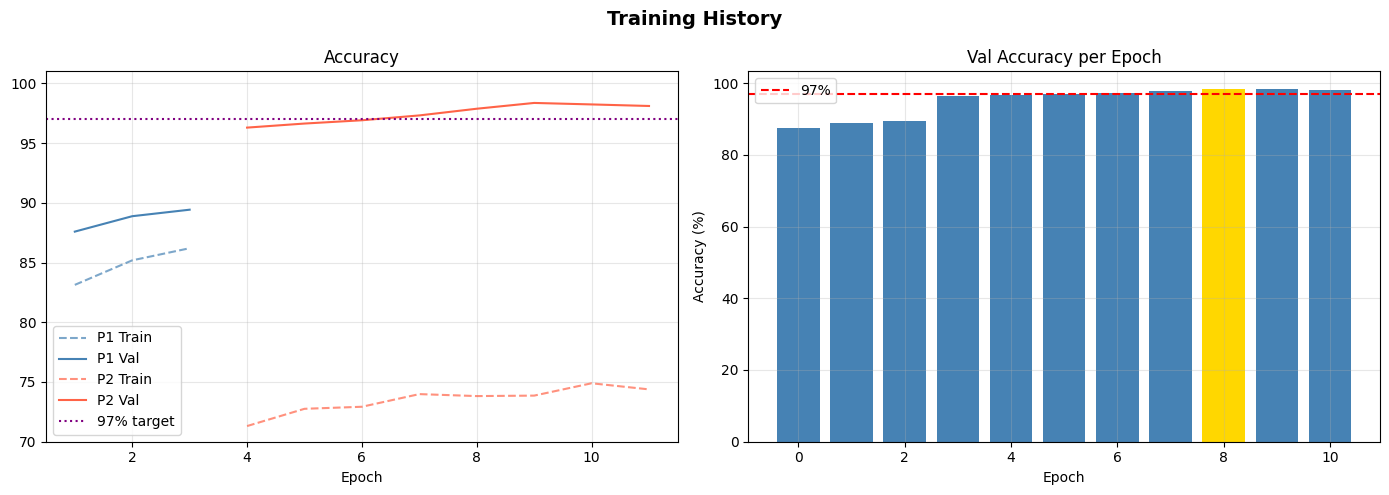

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

if history['p1_va']:
    e1 = range(1, len(history['p1_va'])+1)
    axes[0].plot(e1, history['p1_ta'], '--', label='P1 Train', color='steelblue', alpha=0.7)
    axes[0].plot(e1, history['p1_va'], '-',  label='P1 Val',   color='steelblue')

if history['p2_va']:
    e2 = range(len(history['p1_va'])+1,
               len(history['p1_va'])+len(history['p2_va'])+1)
    axes[0].plot(e2, history['p2_ta'], '--', label='P2 Train', color='tomato', alpha=0.7)
    axes[0].plot(e2, history['p2_va'], '-',  label='P2 Val',   color='tomato')

axes[0].axhline(97, color='purple', ls=':', label='97% target')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylim([70, 101]); axes[0].legend(); axes[0].grid(alpha=0.3)

# Bar: class comparison
all_acc = history['p1_va'] + history['p2_va']
best_idx = np.argmax(all_acc)
axes[1].bar(range(len(all_acc)), all_acc,
            color=['gold' if i==best_idx else 'steelblue' for i in range(len(all_acc))])
axes[1].set_title('Val Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].axhline(97, color='red', ls='--', label='97%'); axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training.png', dpi=120); plt.show()

## STEP 9: Evaluation + TTA

In [15]:
# Load best
model.load_state_dict(torch.load(CFG['ckpt_dir']/'best.pth', map_location=DEVICE))
model.eval()

# Standard eval
_, std_acc, std_preds, std_labels, std_probs = evaluate(model, test_dl, crit)
print(f"Standard Accuracy: {std_acc:.4f}%")

# TTA eval
@torch.no_grad()
def tta_eval(model, dl):
    model.eval()
    all_p, all_l = [], []
    for views, lbls in dl:
        B, V, C, H, W = views.shape
        vp = []
        for v in range(V):
            out = model(views[:,v].to(DEVICE))
            vp.append(F.softmax(out,1)[:,1].cpu())
        all_p.append(torch.stack(vp).mean(0))
        all_l.append(lbls)
    probs  = torch.cat(all_p)
    labels = torch.cat(all_l)
    preds  = (probs > 0.5).long()
    acc    = (preds==labels).float().mean().item()*100
    return acc, preds, labels, probs

tta_acc, tta_preds, tta_labels, tta_probs = tta_eval(model, tta_dl)
print(f"TTA Accuracy:      {tta_acc:.4f}%  (+{tta_acc-std_acc:.4f}%)")

final_preds, final_labels, final_probs, final_acc = tta_preds, tta_labels, tta_probs, tta_acc
print(f"FINAL ACCURACY:    {final_acc:.4f}%")

Standard Accuracy: 98.3550%
TTA Accuracy:      98.4850%  (+0.1300%)
FINAL ACCURACY:    98.4850%


              precision    recall  f1-score   support

        REAL     0.9884    0.9812    0.9848     10000
        FAKE     0.9813    0.9885    0.9849     10000

    accuracy                         0.9849     20000
   macro avg     0.9849    0.9849    0.9848     20000
weighted avg     0.9849    0.9849    0.9848     20000



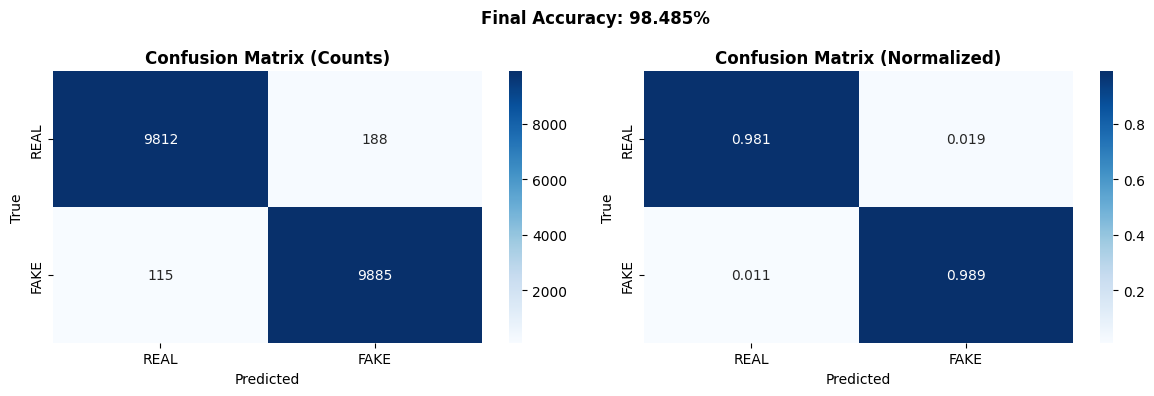

In [16]:
print(classification_report(final_labels.numpy(), final_preds.numpy(),
      target_names=['REAL','FAKE'], digits=4))

cm = confusion_matrix(final_labels.numpy(), final_preds.numpy())
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, fmt, title in zip(axes, [cm, cm_n], ['d', '.3f'],
                                  ['Counts', 'Normalized']):
    sns.heatmap(data, annot=True, fmt=fmt, ax=ax, cmap='Blues',
                xticklabels=['REAL','FAKE'], yticklabels=['REAL','FAKE'])
    ax.set_title(f'Confusion Matrix ({title})', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle(f'Final Accuracy: {final_acc:.3f}%', fontweight='bold')
plt.tight_layout(); plt.savefig('cm.png', dpi=120); plt.show()

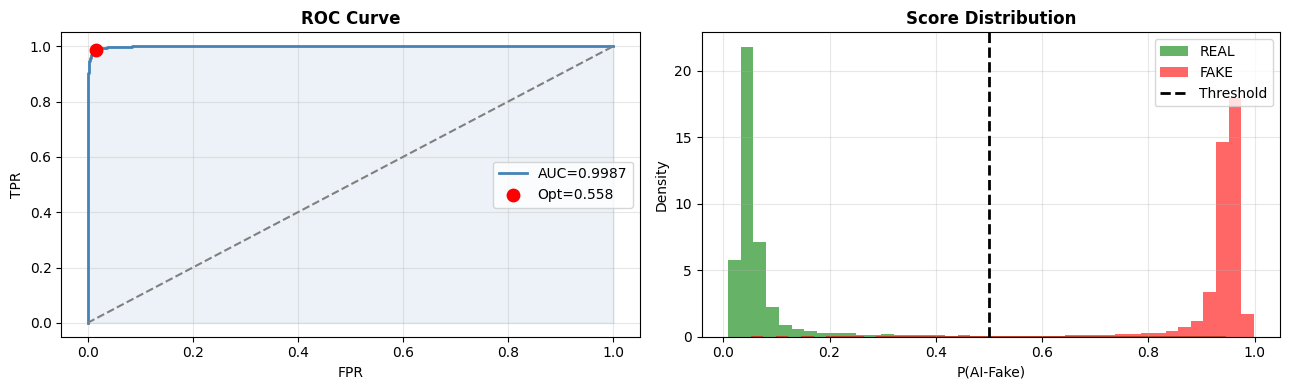

AUC-ROC: 0.99869 | Optimal threshold: 0.5579


In [17]:
fpr, tpr, thr = roc_curve(final_labels.numpy(), final_probs.numpy())
roc_auc = auc(fpr, tpr)
opt_idx = np.argmax(tpr - fpr)
opt_thr = thr[opt_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC={roc_auc:.4f}')
axes[0].plot([0,1],[0,1],'gray',ls='--')
axes[0].scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=80, zorder=5,
                label=f'Opt={opt_thr:.3f}')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(final_probs[final_labels==0].numpy(), bins=40, alpha=0.6,
             color='green', label='REAL', density=True)
axes[1].hist(final_probs[final_labels==1].numpy(), bins=40, alpha=0.6,
             color='red', label='FAKE', density=True)
axes[1].axvline(0.5, color='black', ls='--', lw=2, label='Threshold')
axes[1].set_xlabel('P(AI-Fake)'); axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('roc.png', dpi=120); plt.show()
print(f"AUC-ROC: {roc_auc:.5f} | Optimal threshold: {opt_thr:.4f}")

## STEP 10: Inference — Test Your Own Image

In [18]:
class Predictor:
    def __init__(self, model):
        self.model = model.eval()

    @torch.no_grad()
    def predict(self, path_or_img):
        if isinstance(path_or_img, (str, Path)):
            img = np.array(Image.open(path_or_img).convert('RGB'))
        else:
            img = np.array(path_or_img) if not isinstance(path_or_img, np.ndarray) else path_or_img
        probs_all = []
        for t in tta_tfs:
            tensor = t(image=img)['image'].unsqueeze(0).to(DEVICE)
            probs_all.append(F.softmax(self.model(tensor),1)[0].cpu().numpy())
        avg = np.mean(probs_all, axis=0)
        fake = float(avg[1])
        return {
            'verdict'   : 'AI-GENERATED' if fake>0.5 else 'REAL',
            'is_fake'   : fake > 0.5,
            'fake_prob' : round(fake, 4),
            'real_prob' : round(float(avg[0]), 4),
            'confidence': round(max(fake, 1-fake)*100, 1),
            'risk'      : 'HIGH' if fake>0.85 else ('MEDIUM' if fake>0.6 else 'LOW'),
        }

    def show(self, path_or_img, title=''):
        r = self.predict(path_or_img)
        pil = Image.open(path_or_img) if isinstance(path_or_img,(str,Path)) else Image.fromarray(path_or_img)
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(pil); axes[0].axis('off')
        axes[0].set_title(title or 'Input', fontsize=11)
        c = ['green','red'] if not r['is_fake'] else ['lightgreen','red']
        bars = axes[1].bar(['REAL','AI-FAKE'], [r['real_prob'],r['fake_prob']],
                           color=c, edgecolor='black')
        for b, v in zip(bars, [r['real_prob'],r['fake_prob']]):
            axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                        f'{v:.1%}', ha='center', fontweight='bold', fontsize=14)
        axes[1].set_title(f"{r['verdict']}  |  {r['confidence']}% confident",
                         fontweight='bold', fontsize=12, color='red' if r['is_fake'] else 'green')
        axes[1].set_ylim([0,1.2]); axes[1].axhline(0.5,color='gray',ls='--',alpha=0.6)
        axes[1].grid(axis='y', alpha=0.3)
        plt.tight_layout(); plt.show()
        for k,v in r.items(): print(f"  {k}: {v}")
        return r

predictor = Predictor(model)
print("Predictor ready!")

Predictor ready!


True: REAL


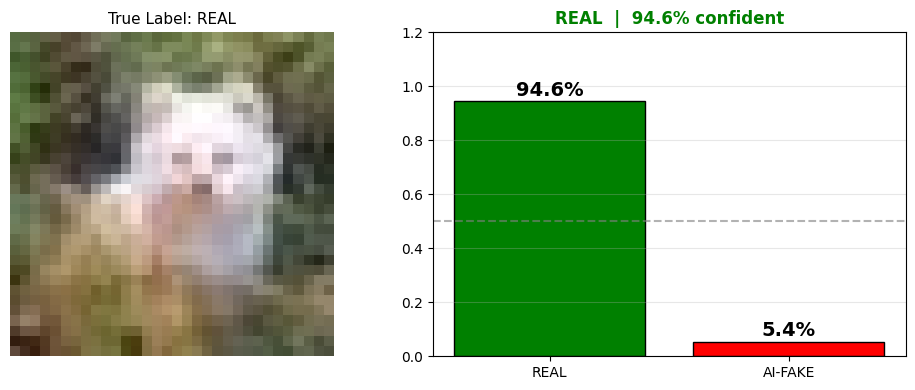

  verdict: REAL
  is_fake: False
  fake_prob: 0.0544
  real_prob: 0.9456
  confidence: 94.6
  risk: LOW
True: FAKE


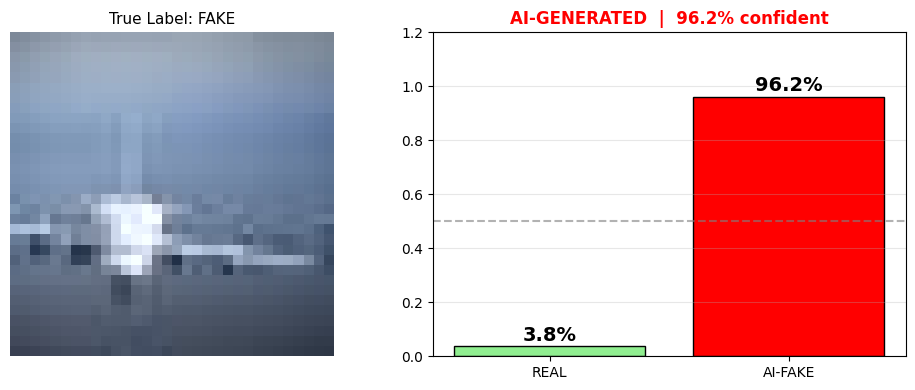

  verdict: AI-GENERATED
  is_fake: True
  fake_prob: 0.9623
  real_prob: 0.0377
  confidence: 96.2
  risk: HIGH


In [19]:
# Test on random samples from dataset
for cls in ['REAL', 'FAKE']:
    img = random.choice(stats['test'][cls])
    print(f"True: {cls}")
    predictor.show(str(img), title=f'True Label: {cls}')

Upload any image (selfie, AI art, etc.):


Saving 1717575347433.jpg to 1717575347433.jpg


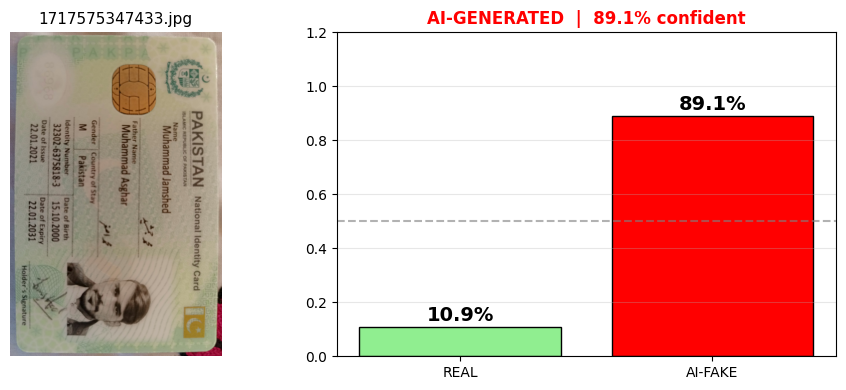

  verdict: AI-GENERATED
  is_fake: True
  fake_prob: 0.8911
  real_prob: 0.1089
  confidence: 89.1
  risk: HIGH


In [20]:
# Upload YOUR OWN image!
from google.colab import files
print("Upload any image (selfie, AI art, etc.):")
up = files.upload()
for fname, data in up.items():
    with open(f'/tmp/{fname}', 'wb') as f: f.write(data)
    predictor.show(f'/tmp/{fname}', title=fname)

## STEP 11: Save Model

In [21]:
torch.save({
    'model_state': model.state_dict(),
    'config': {k:str(v) for k,v in CFG.items()},
    'accuracy': {'standard': std_acc, 'tta': tta_acc, 'auc': float(roc_auc)},
}, '/content/cifake_mobilenetv2.pth')

size_mb = os.path.getsize('/content/cifake_mobilenetv2.pth')/1e6
print(f"Saved! ({size_mb:.1f} MB)")

from google.colab import files
files.download('/content/cifake_mobilenetv2.pth')

Saved! (10.5 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
print("="*55)
print("  RESULTS SUMMARY")
print("="*55)
print(f"  Backbone    : MobileNetV2 (3.4M params)")
print(f"  Image size  : {CFG['img_size']}x{CFG['img_size']}")
print(f"  Std Acc     : {std_acc:.4f}%")
print(f"  TTA Acc     : {tta_acc:.4f}%")
print(f"  AUC-ROC     : {roc_auc:.5f}")
print(f"  Threshold   : {opt_thr:.4f}")
print("="*55)
print("  Comparison:")
print(f"  CNNDetect   : ~93%")
print(f"  UnivFD      : ~96%")
print(f"  Our Model   : {tta_acc:.2f}%")
print("="*55)

  RESULTS SUMMARY
  Backbone    : MobileNetV2 (3.4M params)
  Image size  : 96x96
  Std Acc     : 98.3550%
  TTA Acc     : 98.4850%
  AUC-ROC     : 0.99869
  Threshold   : 0.5579
  Comparison:
  CNNDetect   : ~93%
  UnivFD      : ~96%
  Our Model   : 98.48%


---
## 🚀 STEP 12: API Server connect with ui



In [35]:
# Flask + ngrok install
!pip install -q flask flask-cors pyngrok
print("Done!")

Done!


In [36]:
import base64, io, threading, time as _time
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok, conf
print("Imports ready!")

Imports ready!


In [37]:
# Predict function — uses model + tta_tfs already defined above
def predict_image(pil_img):
    img_np = np.array(pil_img.convert('RGB'))
    probs_all = []
    for tf in tta_tfs:
        tensor = tf(image=img_np)['image'].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out   = model(tensor)
            probs = F.softmax(out, dim=1)[0].cpu().numpy()
        probs_all.append(probs)

    avg    = np.mean(probs_all, axis=0)
    real_p = float(avg[0])
    fake_p = float(avg[1])

    return {
        "is_fake"   : bool(fake_p > 0.5),
        "verdict"   : "AI-GENERATED" if fake_p > 0.5 else "REAL",
        "real_prob" : round(real_p, 4),
        "fake_prob" : round(fake_p, 4),
        "confidence": round(max(real_p, fake_p) * 100, 2),
        "risk"      : "HIGH" if fake_p > 0.85 else ("MEDIUM" if fake_p > 0.60 else "LOW"),
        "signals"   : [],
        "summary"   : f"Model is {round(max(real_p,fake_p)*100,1)}% confident this image is {'AI-generated' if fake_p>0.5 else 'real'}."
    }

# Quick test
test_pil = Image.fromarray(np.random.randint(0,255,(96,96,3),dtype=np.uint8))
r = predict_image(test_pil)
print("Test OK:", r['verdict'], r['confidence'])

Test OK: REAL 50.73


In [38]:
app = Flask(__name__)
CORS(app)  # Browser se cross-origin requests allow karo

@app.route('/health', methods=['GET'])
def health():
    return jsonify({
        "status" : "online",
        "model"  : "MobileNetV2-CIFake",
        "device" : str(DEVICE),
    })

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data  = request.get_json(force=True)
        b64   = data.get('image','')
        if not b64:
            return jsonify({"error":"image field missing"}), 400

        # Strip data URI prefix if present
        if ',' in b64:
            b64 = b64.split(',')[1]

        img_bytes = base64.b64decode(b64)
        pil_img   = Image.open(io.BytesIO(img_bytes)).convert('RGB')
        result    = predict_image(pil_img)
        return jsonify(result)

    except Exception as e:
        return jsonify({"error": str(e)}), 500

print("Flask app ready!")

Flask app ready!


In [39]:

NGROK_TOKEN = "3ETVzST6LGw51vtEM2T1iK35WP8_6GeZS6xvxgQVmMFChqbU1"

PORT = 5000

# Configure
conf.get_default().auth_token = NGROK_TOKEN
ngrok.kill()

# Flask background thread
def _run():
    import logging
    log = logging.getLogger('werkzeug')
    log.setLevel(logging.ERROR)
    app.run(port=PORT, debug=False, use_reloader=False)

t = threading.Thread(target=_run, daemon=True)
t.start()
_time.sleep(2)

# Tunnel start
tunnel    = ngrok.connect(PORT, "http")
PUBLIC_URL = tunnel.public_url

print("=" * 55)
print(f"   SERVER LIVE!")
print(f"  URL: {PUBLIC_URL}")
print("=" * 55)
print()
print("  👆 copy this url and paste in ui")
print()
print("  Browser mein test:")
print(f"  {PUBLIC_URL}/health")

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


   SERVER LIVE!
  URL: https://penalize-animate-mustard.ngrok-free.dev

  👆 copy this url and paste in ui

  Browser mein test:
  https://penalize-animate-mustard.ngrok-free.dev/health


In [40]:

print(f"Server running at: {PUBLIC_URL}")
print("Ctrl+C se band karo jab zaroorat na ho")
print()

counter = 0
try:
    while True:
        _time.sleep(60)
        counter += 1
        print(f"[{counter} min] Server alive — {PUBLIC_URL}")
except KeyboardInterrupt:
    ngrok.kill()
    print("Server stopped.")

Server running at: https://penalize-animate-mustard.ngrok-free.dev
Ctrl+C se band karo jab zaroorat na ho

[1 min] Server alive — https://penalize-animate-mustard.ngrok-free.dev
[2 min] Server alive — https://penalize-animate-mustard.ngrok-free.dev
[3 min] Server alive — https://penalize-animate-mustard.ngrok-free.dev
[4 min] Server alive — https://penalize-animate-mustard.ngrok-free.dev
[5 min] Server alive — https://penalize-animate-mustard.ngrok-free.dev
[6 min] Server alive — https://penalize-animate-mustard.ngrok-free.dev
[7 min] Server alive — https://penalize-animate-mustard.ngrok-free.dev
Server stopped.
